#  Python in Environmental Applications

## Revisão: 
- Arquivos vetoriais: dados geométricos (pontos - localização de poços, linhas - rios ou estradas, polígonos - bairros ou limites de bacias hidrográficas)
- Formato comum: .shp, .shx, .dbf, .prj
- Usado: limites, áreas, rotas, unidades de conservação, etc
- 
- Arquivos Raster: matrizes de pixels - cada pixel tem um valor numérico (como mapa de uso do solo, imagens de satélite, altitude (DEM))
- Formato comum: .tif, .img, .nc, .asc
- Usado: dados contínuos no espaço (altitude, temperatura,NDVI, refletância)
- 
  
- É possível ler um raster de NDVI, ler um shapefile de município e recortar o raster usando o shapefile

    ### obs:
- extensão do xarray para georeferenciamento (CRS-sistema de coordenadas, recortes espaciais, reprojeção, clip com shapefile, lê rasters geográficos)
- import rioxarray

- abrir e manupular shapefiles (.shp, ver tabela de atributos, plotar o shapefile, fazer recortes e união espacial)
- import geopandas


## Atividade Final 
Nesta atividade é necessário analisar dados de arquivos vetoriais e ou rasters

Avaliação:
- Utilizou e abriu o arquivo corretamente?
- Explorou alguma estatística ou recortou o dado?
- Analisou os resultados com profundidade?
- Demonstrou curisidade e interesse em fazer a atividade 

In [148]:
# abre .nc (variaveis, dimensoes, atributos) - xarray é mais intuitivo 
import netCDF4 as nc

# serve para abrir raster multibanda (.tif, .nc, .grib...) - usado em dados ambientais (temperatura, precipitação, MODIS, ERA5)
import xarray as xr


import matplotlib.pyplot as plt
import numpy as np

# matplotlib para plotagem, transforma dados numéricos (numpy) em rpresentações visuais
# numpy é para cálculos numéricos com arrays multidimensionais

### Selecionando o arquivo: Brain netCDF - Dióxido de Nitrogênio (NO2)

In [149]:
raster = xr.open_dataset(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\Aula06\BRAIN_BASECONC_NO2_2023_01_01_00_to_2023_12_30_23.nc")

print(raster)

<xarray.Dataset> Size: 2GB
Dimensions:  (TSTEP: 8736, ROW: 247, COL: 257, LAY: 1)
Dimensions without coordinates: TSTEP, ROW, COL, LAY
Data variables:
    TFLAG    (TSTEP) int32 35kB ...
    LON      (ROW, COL) float32 254kB ...
    LAT      (ROW, COL) float32 254kB ...
    NO2      (TSTEP, LAY, ROW, COL) float32 2GB ...
Attributes: (12/33)
    IOAPI_VERSION:  ioapi-3.2: $Id: init3.F90 200 2021-05-10 14:06:20Z co
    EXEC_ID:        CMAQ_CCTMv54_sha=fb7856ef5c_root_20240901_173556_49697998...
    FTYPE:          1
    CDATE:          2024245
    CTIME:          173556
    WDATE:          2024245
    ...             ...
    VGLVLS:         [1.        0.9975215]
    GDNAM:          BR_20km         
    UPNAM:          OPACONC         
    HISTORY:        
    FILEDESC:       Concentration of NO2 created by Leonardo Hoinaski - 2025-...
    VAR-LIST:       NO2


In [150]:
# Informações das variáveis que estou trabalhando 
# (TSTEP = passos no tempo, LAY = camada, ROW = linhas(N-S), COL = colunas(W-E))

no2 = raster["NO2"]
print(no2)

<xarray.DataArray 'NO2' (TSTEP: 8736, LAY: 1, ROW: 247, COL: 257)> Size: 2GB
[554552544 values with dtype=float32]
Dimensions without coordinates: TSTEP, LAY, ROW, COL
Attributes:
    units:    ppm


In [151]:
# remove a dimensão LAY (fica só TSTEP, ROW, COL)   -  porque LAY só tem 1 valor = fixa
no2 = no2.squeeze("LAY")

print(no2)
print("Dimensões depois do squeeze:", no2.sizes)

<xarray.DataArray 'NO2' (TSTEP: 8736, ROW: 247, COL: 257)> Size: 2GB
[554552544 values with dtype=float32]
Dimensions without coordinates: TSTEP, ROW, COL
Attributes:
    units:    ppm
Dimensões depois do squeeze: Frozen({'TSTEP': 8736, 'ROW': 247, 'COL': 257})


In [227]:
# Quero plotar gráficos com as coordenadas, então anexo (quero usar lat e lon, não linhas e colunas)
lat = raster["LAT"]     
lon = raster["LON"]    

no2 = no2.assign_coords(lat=(("ROW", "COL"), lat.values),lon=(("ROW", "COL"), lon.values))

print(no2)

<xarray.DataArray 'NO2' (TSTEP: 8736, ROW: 247, COL: 257)> Size: 2GB
array([[[6.858866e-05, 6.761702e-05, ..., 2.903573e-05, 3.264225e-05],
        [6.742035e-05, 6.500901e-05, ..., 2.970608e-05, 3.339768e-05],
        ...,
        [8.926667e-05, 2.136797e-04, ..., 7.693572e-05, 7.437065e-05],
        [2.293399e-04, 2.624847e-04, ..., 7.326098e-05, 7.509514e-05]],

       [[6.689312e-05, 6.619081e-05, ..., 4.032608e-05, 4.340286e-05],
        [6.337611e-05, 6.128241e-05, ..., 3.796443e-05, 4.135938e-05],
        ...,
        [1.110191e-04, 4.073721e-04, ..., 7.689472e-05, 7.435658e-05],
        [4.376713e-04, 4.910149e-04, ..., 7.297206e-05, 7.503816e-05]],

       ...,

       [[5.584232e-05, 5.484805e-05, ..., 3.833249e-05, 3.669459e-05],
        [5.275160e-05, 4.815102e-05, ..., 3.074497e-05, 2.950322e-05],
        ...,
        [6.566380e-04, 5.542138e-04, ..., 6.923611e-05, 6.917900e-05],
        [5.365646e-04, 5.246936e-04, ..., 6.936188e-05, 7.033659e-05]],

       [[6.487751e-05

<xarray.DataArray 'NO2' (ROW: 247, COL: 257)> Size: 254kB
array([[6.858866e-05, 6.761702e-05, 6.818053e-05, ..., 2.795238e-05,
        2.903573e-05, 3.264225e-05],
       [6.742035e-05, 6.500901e-05, 6.583339e-05, ..., 2.640854e-05,
        2.970608e-05, 3.339768e-05],
       [6.791166e-05, 6.513559e-05, 6.497222e-05, ..., 3.606400e-05,
        3.748589e-05, 4.215880e-05],
       ...,
       [2.359516e-04, 2.195322e-04, 3.113641e-04, ..., 7.726808e-05,
        7.675517e-05, 7.426193e-05],
       [8.926667e-05, 2.136797e-04, 3.299770e-04, ..., 7.537286e-05,
        7.693572e-05, 7.437065e-05],
       [2.293399e-04, 2.624847e-04, 2.695345e-04, ..., 7.249146e-05,
        7.326098e-05, 7.509514e-05]], shape=(247, 257), dtype=float32)
Coordinates:
    lat      (ROW, COL) float32 254kB -34.36 -34.36 -34.36 ... 7.609 7.609 7.609
    lon      (ROW, COL) float32 254kB -77.97 -77.79 -77.61 ... -32.1 -31.92
Dimensions without coordinates: ROW, COL
Attributes:
    units:    ppm


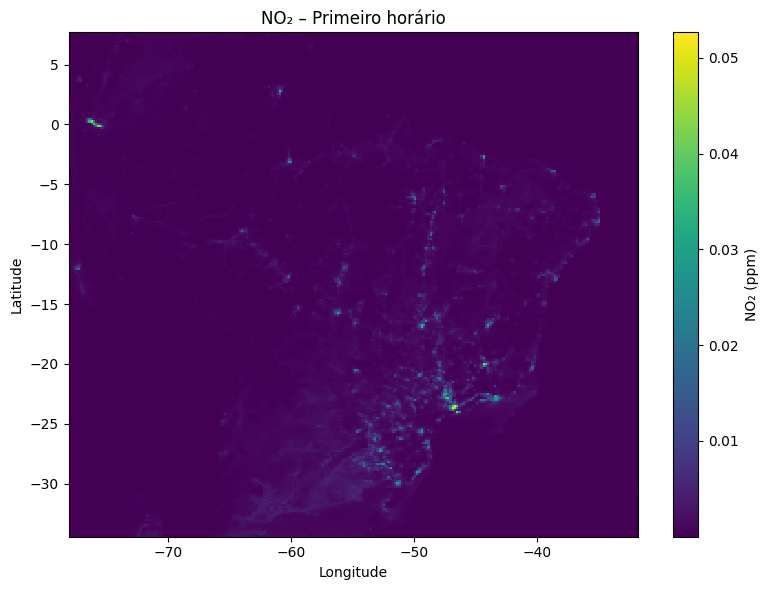

In [226]:
# Ver comportamento no primeiro tempo   - .isel = seleciona dados usando indíces, não valores 
# .sel usaria os valores (time=...)

no2_t0 = no2.isel(TSTEP=0)
print(no2_t0)

plt.figure(figsize=(8,6))
no2_t0.plot( x="lon", y="lat", cmap="viridis", cbar_kwargs={"label": "NO₂ (ppm)"})  # cmap=color map

plt.title("NO₂ – Primeiro horário")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [154]:
# Estatísticas do primeiro tempo
print("  Mínimo:", float(no2_t0.min()), "ppm")
print("  Máximo:", float(no2_t0.max()), "ppm")
print("  Média :", float(no2_t0.mean()), "ppm")

  Mínimo: 6.140632649476174e-06 ppm
  Máximo: 0.052652761340141296 ppm
  Média : 0.0005039325915277004 ppm


## Cartopy = biblioteca de mapas

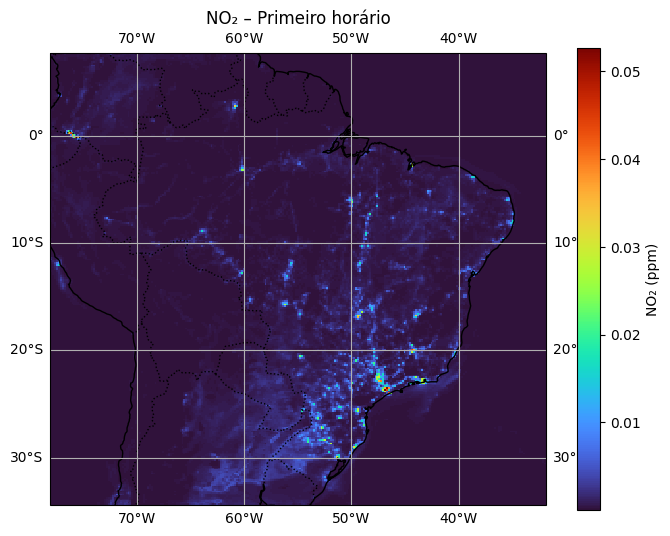

In [155]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(no2_t0.lon, no2_t0.lat, no2_t0, cmap="turbo", shading="auto")
plt.colorbar(img, label="NO₂ (ppm)")

ax.add_feature(cfeature.COASTLINE)       # contornos
ax.add_feature(cfeature.BORDERS, linestyle=':')  # fronteiras
ax.gridlines(draw_labels=True)

plt.title("NO₂ – Primeiro horário")
plt.show()

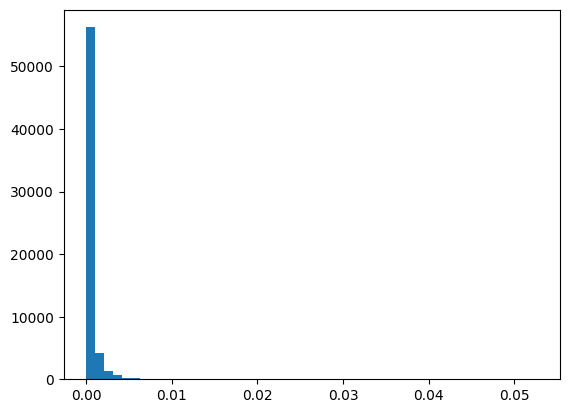

In [156]:
hist = no2_t0.values.ravel()
plt.hist(hist, bins=50)
plt.show()

- Histograma mostra que quase todos os valores estão entre 0.0 e 0.01 ppm
- Distribuição assimétrica
- Sem limites visuais (ajuste de contraste), fica péssima a visualização
- Gráfico mostra que ajuste é necessário

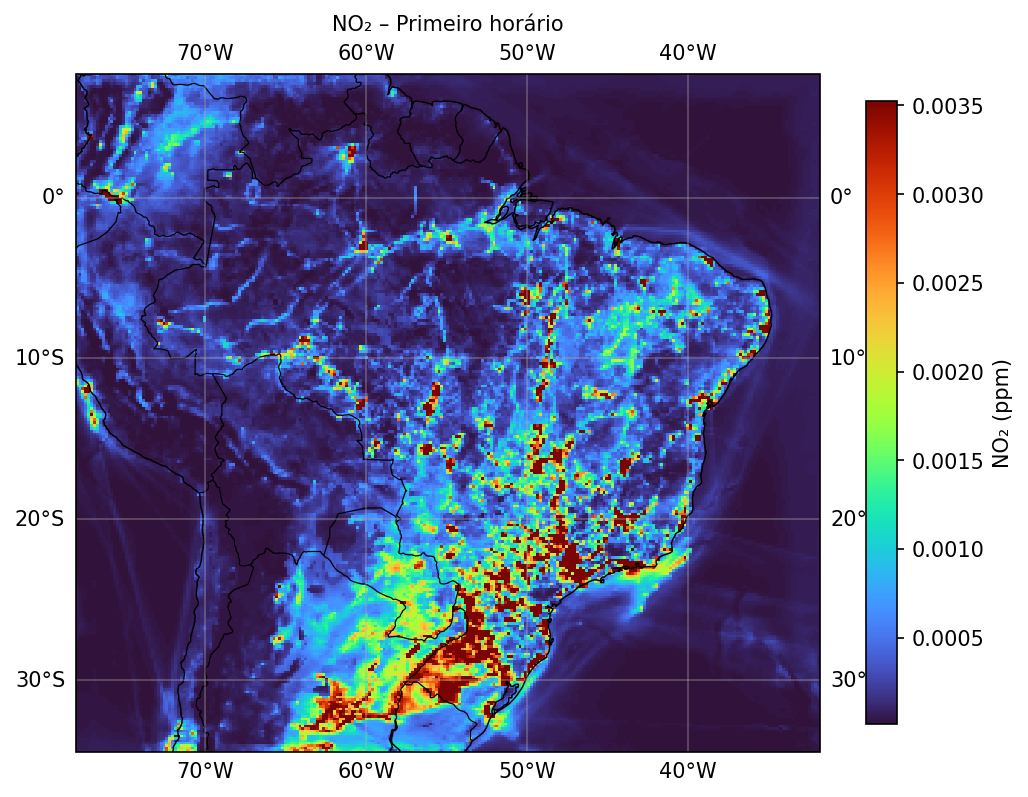

In [157]:
vmin = float(no2_t0.quantile(0.02))  # ajuste de contraste (limites visuais da escala de cores do mapa)
vmax = float(no2_t0.quantile(0.98))

plt.figure(figsize=(8,6), dpi=150)  # pontos por polegada
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(no2_t0.lon, no2_t0.lat, no2_t0, cmap="turbo", vmin=vmin, vmax=vmax, shading="auto")
plt.colorbar(img, label="NO₂ (ppm)", shrink=0.9)

ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.4)

plt.title("NO₂ – Primeiro horário", fontsize=10)
plt.show()

Considerações - Maiores concentrações de NO2 nas regiões Sul e Sudeste. Valores muito mais baixos no Norte,
compatível com menor urbanização e maior cobertura vegetal.

# Mapa da Média Temporal de NO2

In [158]:
# média ao longo do ano inteiro (todas as TSTEP)
no2_mean_time = no2.mean(dim="TSTEP") 
print(no2_mean_time)

<xarray.DataArray 'NO2' (ROW: 247, COL: 257)> Size: 254kB
array([[6.0820228e-05, 5.9684560e-05, 5.9048532e-05, ..., 4.6450110e-05,
        4.7135927e-05, 4.8977607e-05],
       [5.6285124e-05, 5.4775093e-05, 5.4456676e-05, ..., 4.2262560e-05,
        4.3356231e-05, 4.5444947e-05],
       [5.5479784e-05, 5.4381955e-05, 5.3511587e-05, ..., 4.1739808e-05,
        4.2663825e-05, 4.5007662e-05],
       ...,
       [1.3957310e-03, 1.2036652e-03, 1.3627949e-03, ..., 5.1200364e-05,
        5.4499546e-05, 5.6734018e-05],
       [1.1650560e-03, 1.1353438e-03, 1.4109650e-03, ..., 5.1774034e-05,
        5.4636090e-05, 5.7338100e-05],
       [1.1636593e-03, 1.2194818e-03, 1.2785404e-03, ..., 5.2799653e-05,
        5.4968659e-05, 5.7381807e-05]], shape=(247, 257), dtype=float32)
Coordinates:
    lat      (ROW, COL) float32 254kB -34.36 -34.36 -34.36 ... 7.609 7.609 7.609
    lon      (ROW, COL) float32 254kB -77.97 -77.79 -77.61 ... -32.1 -31.92
Dimensions without coordinates: ROW, COL


In [159]:
vmin_mean = float(no2_mean_time.quantile(0.02)) 
vmax_mean = float(no2_mean_time.quantile(0.98))   

print("vmin (mean):", vmin_mean)
print("vmax (mean):", vmax_mean)

vmin (mean): 1.9318781414767728e-05
vmax (mean): 0.017748399749398232


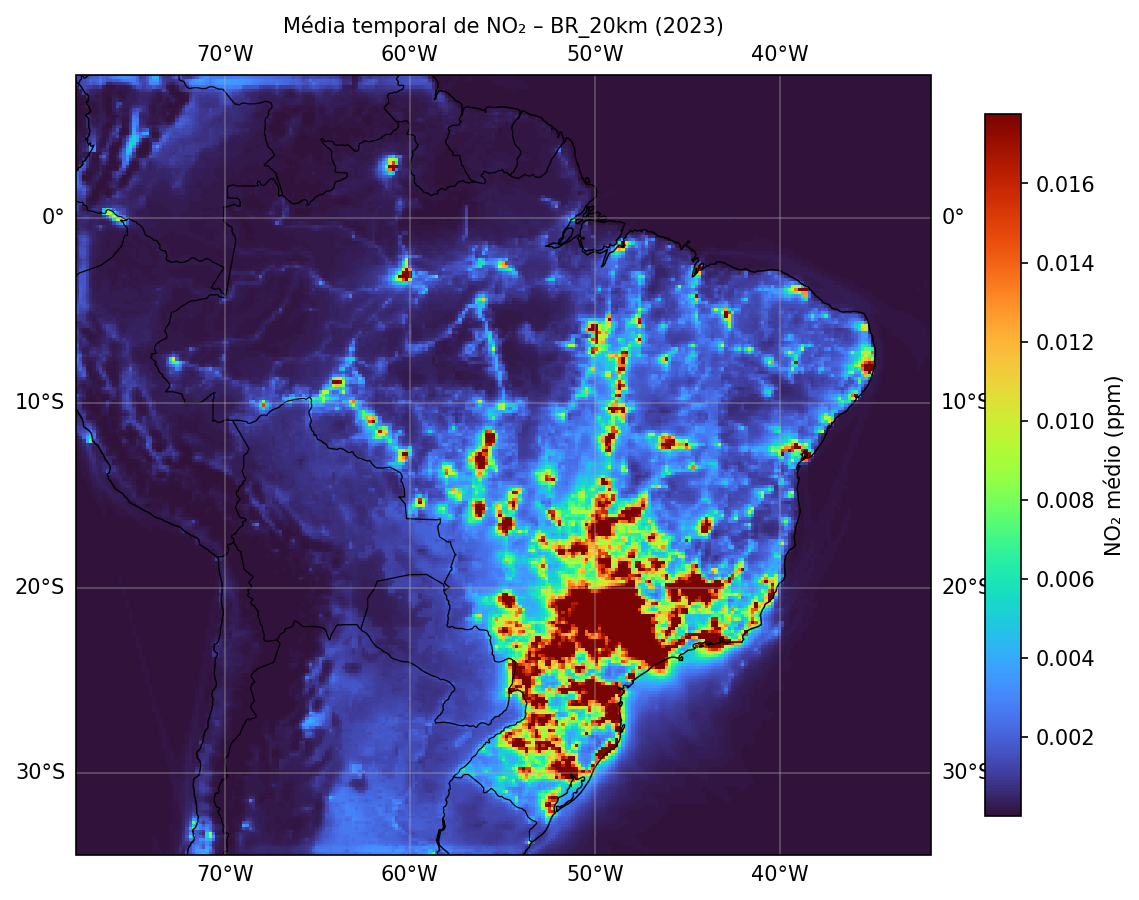

In [160]:
plt.figure(figsize=(8,6), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(no2_mean_time.lon, no2_mean_time.lat, no2_mean_time, cmap="turbo", vmin=vmin_mean, vmax=vmax_mean, shading="auto")

plt.colorbar(img, label="NO₂ médio (ppm)", shrink=0.9)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.4)

plt.title("Média temporal de NO₂ – BR_20km (2023)", fontsize=10)
plt.tight_layout()
plt.show()

# Mapa do Desvio-padrão Temporal de NO2

<xarray.DataArray 'NO2' (ROW: 247, COL: 257)> Size: 254kB
array([[1.32923060e-05, 1.48005593e-05, 1.50811775e-05, ...,
        1.88177746e-05, 1.82334043e-05, 1.79835388e-05],
       [1.45753511e-05, 1.61073804e-05, 1.67995477e-05, ...,
        1.79463896e-05, 1.79132821e-05, 1.80098723e-05],
       [1.60192594e-05, 1.84112978e-05, 1.92051593e-05, ...,
        1.80397110e-05, 1.80623647e-05, 1.81170926e-05],
       ...,
       [1.46159634e-03, 1.27156917e-03, 1.48591038e-03, ...,
        2.45606534e-05, 2.35084390e-05, 2.19580816e-05],
       [1.20400568e-03, 1.19547336e-03, 1.45052641e-03, ...,
        2.42803253e-05, 2.33100327e-05, 2.20032580e-05],
       [1.23606168e-03, 1.26138504e-03, 1.33409922e-03, ...,
        2.34639356e-05, 2.27342207e-05, 2.18265341e-05]],
      shape=(247, 257), dtype=float32)
Coordinates:
    lat      (ROW, COL) float32 254kB -34.36 -34.36 -34.36 ... 7.609 7.609 7.609
    lon      (ROW, COL) float32 254kB -77.97 -77.79 -77.61 ... -32.1 -31.92
Dimensions w

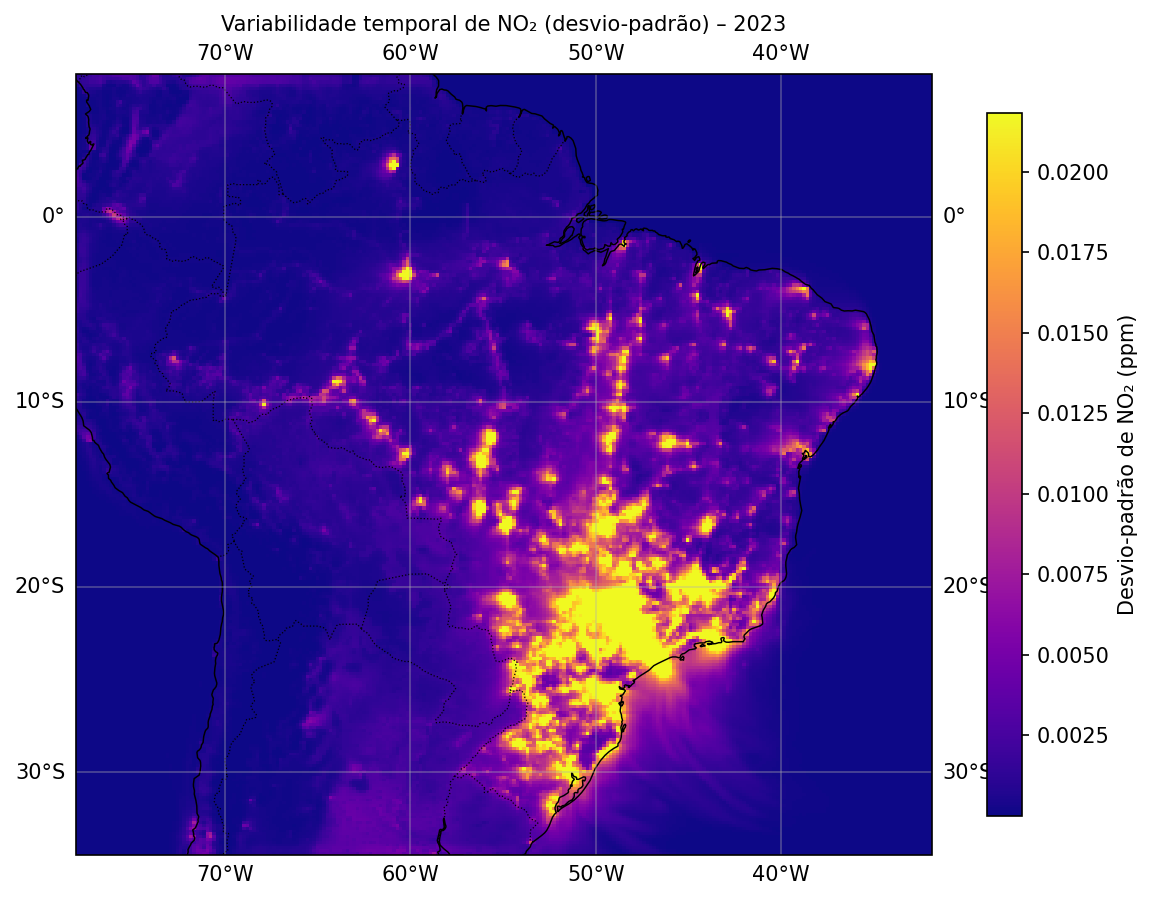

In [161]:
no2_std_time = no2.std(dim="TSTEP")    
print(no2_std_time)

vmin_std = float(no2_std_time.quantile(0.02))
vmax_std = float(no2_std_time.quantile(0.98))

plt.figure(figsize=(8,6), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

img = ax.pcolormesh(no2_std_time.lon, no2_std_time.lat, no2_std_time, cmap="plasma", vmin=vmin_std, vmax=vmax_std, shading="auto")

plt.colorbar(img, label="Desvio-padrão de NO₂ (ppm)", shrink=0.9)

ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.4)

plt.title("Variabilidade temporal de NO₂ (desvio-padrão) – 2023", fontsize=10)
plt.tight_layout()
plt.show()

Gráfico onde o NO₂ varia mais ao longo do tempo (grandes oscilações) x onde é mais estável. Conclusão: onde a concentração média é alta, a variabilidade também é alta. Emissões altas, irregulares (dias com pico, dias com queda), influência de metereologia (vento, inversão térmica)

In [162]:
# Gráficos de média e desvio parecidos - correlação
corr = np.corrcoef(no2_mean_time.values.ravel(),\
no2_std_time.values.ravel())
print(corr)

[[1.         0.98257809]
 [0.98257809 1.        ]]


Temos uma correlação muito alta de 0.9826. Comportamento característico de poluentes que dependem de atividade antrópicas irregulares (tráfego, indústrias, queimadas)

# Série temporal da média 

In [220]:
import pandas as pd
# eixo de tempo: 1 ano de dados horários
tempo = pd.date_range(start="2023-01-01 00:00", periods=no2.sizes["TSTEP"], freq="h")

# média espacial Brasil- 1 valor por tempo
no2_br_series = no2.mean(dim=["ROW", "COL"])
no2_br_series = no2_br_series.assign_coords(TSTEP=tempo).rename({"TSTEP": "time"})

print(no2_br_series)

<xarray.DataArray 'NO2' (time: 8736)> Size: 35kB
array([0.00050393, 0.00086462, 0.00108276, ..., 0.00085703, 0.00144162,
       0.00176119], shape=(8736,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-30T23:00:00


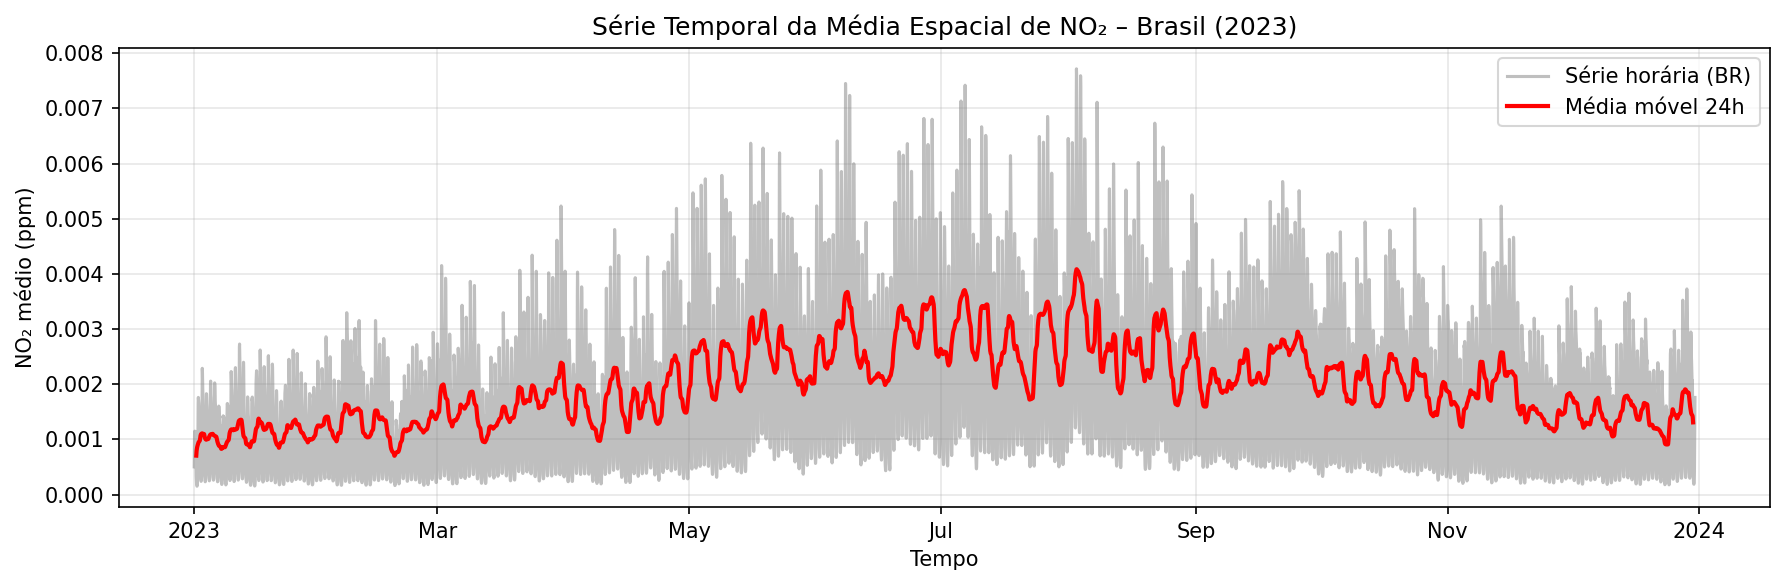

Média anual BR: 0.001985576469451189 ppm
Máximo horário BR: 0.0077169775031507015 ppm
Mínimo horário BR: 0.0001524266554042697 ppm
Desvio-padrão temporal BR: 0.001401313696987927 ppm


In [164]:
plt.figure(figsize=(12,4), dpi=150)
no2_br_series.plot(color="gray", alpha=0.5, label="Série horária (BR)")

# média móvel 24h (janela centrada)
no2_br_smooth = no2_br_series.rolling(time=24, center=True).mean()
no2_br_smooth.plot(color="red", linewidth=2, label="Média móvel 24h")

plt.title("Série Temporal da Média Espacial de NO₂ – Brasil (2023)")
plt.ylabel("NO₂ médio (ppm)")
plt.xlabel("Tempo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Média anual BR:", float(no2_br_series.mean()), "ppm")
print("Máximo horário BR:", float(no2_br_series.max()), "ppm")
print("Mínimo horário BR:", float(no2_br_series.min()), "ppm")
print("Desvio-padrão temporal BR:", float(no2_br_series.std()), "ppm")

# Ciclo diário de NO2

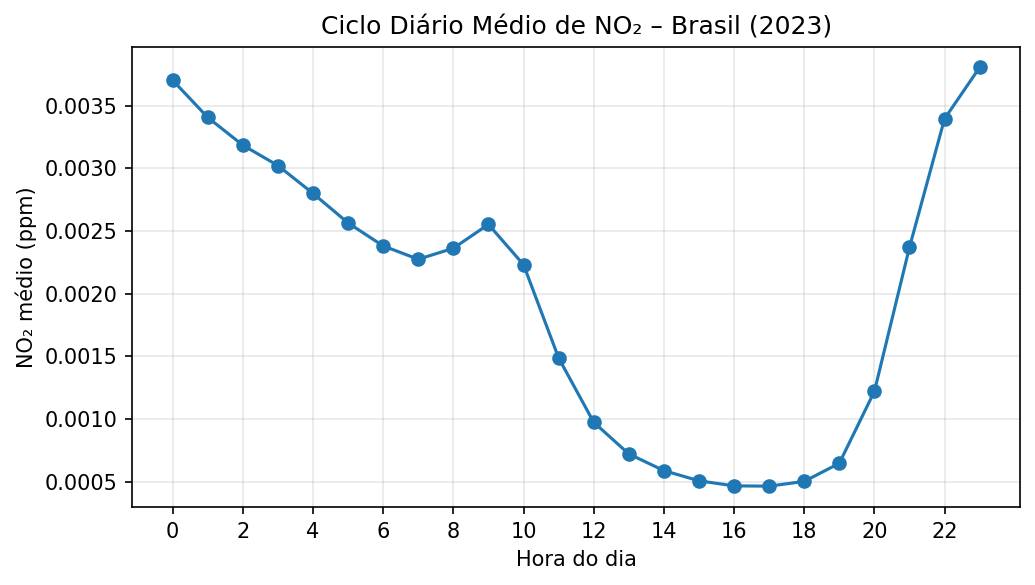

<xarray.DataArray 'NO2' (hour: 24)> Size: 96B
array([0.00370465, 0.0034076 , 0.00318608, 0.00302369, 0.0028012 ,
       0.00256543, 0.002382  , 0.00227559, 0.00236348, 0.0025538 ,
       0.00223247, 0.00148837, 0.00097466, 0.00072201, 0.00058883,
       0.00050734, 0.00046689, 0.00046469, 0.00050254, 0.00064701,
       0.00122064, 0.00237112, 0.00339716, 0.0038066 ], dtype=float32)
Coordinates:
  * hour     (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23


In [166]:
# hora do dia (0–23) como coordenada
horas = no2_br_series["time"].dt.hour.values
no2_br_hourly = no2_br_series.assign_coords(hour=("time", horas))

# ciclo diário: média de todas as horas 0, 1, ..., 23 ao longo do ano
ciclo_diario = no2_br_hourly.groupby("hour").mean()

plt.figure(figsize=(7,4), dpi=150)
ciclo_diario.plot(marker="o")
plt.title("Ciclo Diário Médio de NO₂ – Brasil (2023)")
plt.xlabel("Hora do dia")
plt.ylabel("NO₂ médio (ppm)")
plt.grid(alpha=0.3)
plt.xticks(range(0,24,2))
plt.tight_layout()
plt.show()

print(ciclo_diario)

# Cortes por região com máscaras de lat/lon

In [215]:
regions = {"Sul": {"lat_min": -34, "lat_max": -22, "lon_min": -60, "lon_max": -45,},\
        "Sudeste": {"lat_min": -25, "lat_max": -15,"lon_min": -52, "lon_max": -39,},}

region_series = {}

for name, box in regions.items():
    mask = ((no2.lat >= box["lat_min"]) & (no2.lat <= box["lat_max"]) & (no2.lon >= box["lon_min"]) & (no2.lon <= box["lon_max"]))
    no2_reg = no2.where(mask)
    series_reg = no2_reg.mean(dim=["ROW", "COL"])
    series_reg = series_reg.assign_coords(TSTEP=tempo).rename({"TSTEP": "time"})
    region_series[name] = series_reg

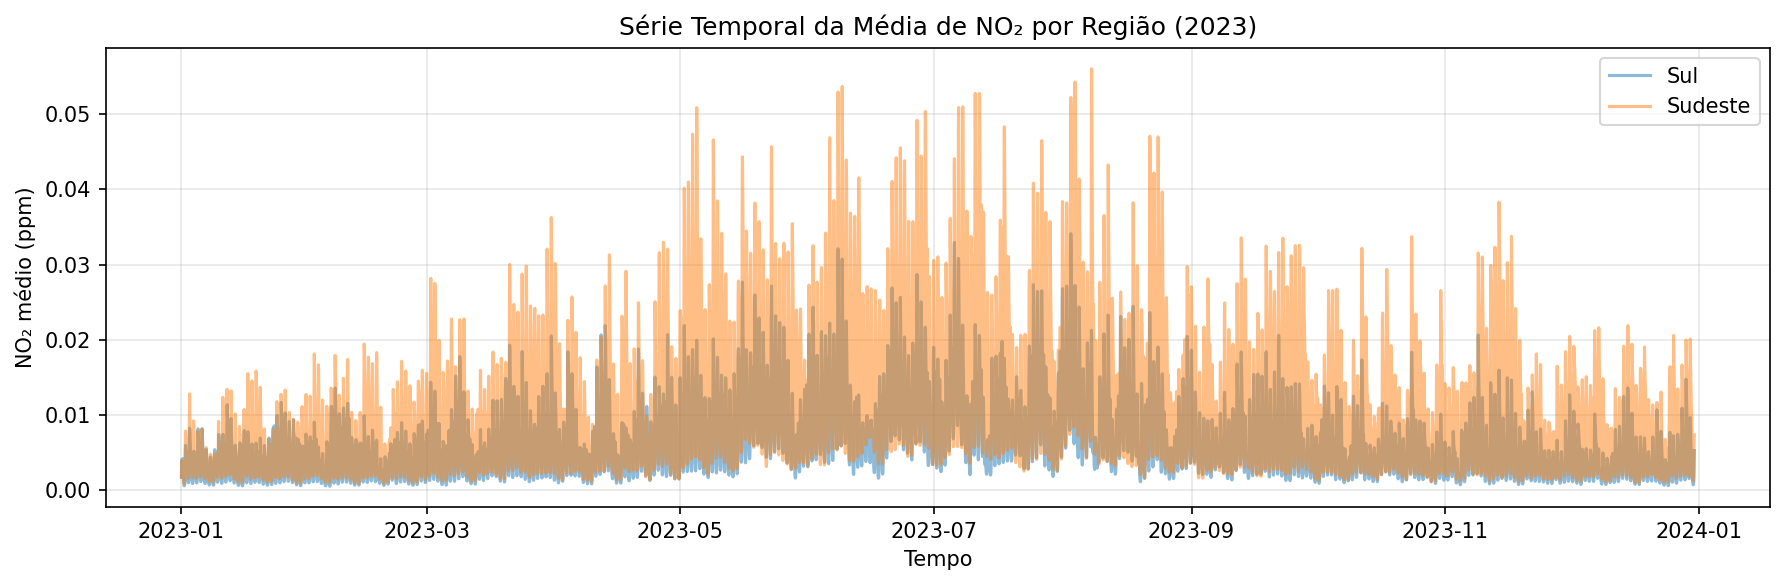

In [222]:
plt.figure(figsize=(12,4), dpi=150)

for name, s in region_series.items():
    plt.plot(s["time"], s, label=name, alpha=0.5)

plt.title("Série Temporal da Média de NO₂ por Região (2023)")
plt.ylabel("NO₂ médio (ppm)")
plt.xlabel("Tempo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Shapefile para corte do estado de Santa Catarina

Shapefile disponibilizado pelo IBGE: https://www.ibge.gov.br/geociencias/organizacao-do-territorio/malhas-territoriais/15774-malhas.html

In [177]:
import geopandas as gpd

shp_uf = r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\Aula06\SC_UF"
br_ufs = gpd.read_file(shp_uf).to_crs(epsg=4326)

sc = br_ufs[br_ufs["SIGLA_UF"] == "SC"].copy()
sc_geom = sc.geometry.iloc[0]

In [178]:
# pega lat/lon 2D
lats = no2.lat.values
lons = no2.lon.values

# cria GeoDataFrame de pontos (um ponto por pixel)
points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(lons.ravel(), lats.ravel()), crs="EPSG:4326")

# máscara booleana: True se o ponto está dentro de SC
mask_flat = points.within(sc_geom)
mask_sc = mask_flat.values.reshape(lats.shape)  # volta para shape (ROW, COL)

# aplica a máscara ao NO2 (mantém TSTEP)
no2_sc = no2.where(mask_sc)

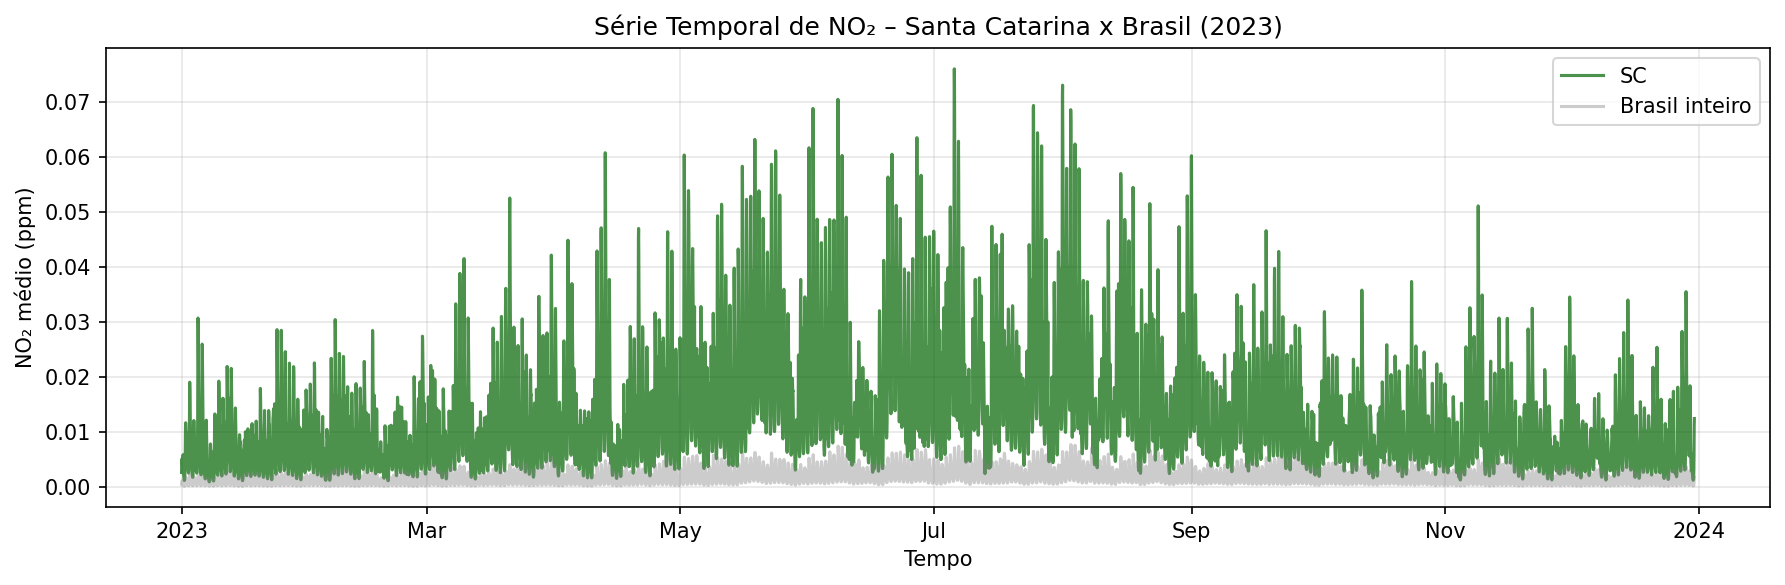

Média anual SC: 0.013336209580302238 ppm


In [190]:
no2_sc_series = no2_sc.mean(dim=["ROW", "COL"])
no2_sc_series = no2_sc_series.assign_coords(TSTEP=tempo).rename({"TSTEP": "time"})

plt.figure(figsize=(12,4), dpi=150)
no2_sc_series.plot(color="darkgreen", alpha=0.7, label="SC")
no2_br_series.plot(color="gray", alpha=0.4, label="Brasil inteiro")

plt.title("Série Temporal de NO₂ – Santa Catarina x Brasil (2023)")
plt.ylabel("NO₂ médio (ppm)")
plt.xlabel("Tempo")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Média anual SC:", float(no2_sc_series.mean()), "ppm")

In [191]:
# Caminho do shapefile de municípios de SC
shp_sc = r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\Aula06\SC_municipios"
sc = gpd.read_file(shp_sc)

# garantir CRS geográfico
sc = sc.to_crs(epsg=4326)

print(sc.head())

    CD_MUN       NM_MUN  CD_RGI               NM_RGI CD_RGINT  NM_RGINT CD_UF  \
0  4209508   Laurentino  420022           Rio do Sul     4207  Blumenau    42   
1  4202107  Barra Velha  420020               Itajaí     4207  Blumenau    42   
2  4217808         Taió  420022           Rio do Sul     4207  Blumenau    42   
3  4202156     Belmonte  420009  São Miguel do Oeste     4204   Chapecó    42   
4  4204707   Cunha Porã  420012            Maravilha     4204   Chapecó    42   

            NM_UF SIGLA_UF CD_REGIA NM_REGIA SIGLA_RG CD_CONCU  \
0  Santa Catarina       SC        4      Sul        S     None   
1  Santa Catarina       SC        4      Sul        S  4208203   
2  Santa Catarina       SC        4      Sul        S     None   
3  Santa Catarina       SC        4      Sul        S     None   
4  Santa Catarina       SC        4      Sul        S     None   

                         NM_CONCU  AREA_KM2  \
0                            None    79.333   
1  Itajaí - Balneário 

C:\Users\satiu\AppData\Local\Temp\ipykernel_1840\229450869.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sc_cent["geometry"] = sc_cent.geometry.centroid  # 1 ponto por município
C:\Users\satiu\Documents\GitHub\python_env_app\venv\Lib\site-packages\geopandas\array.py:408: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


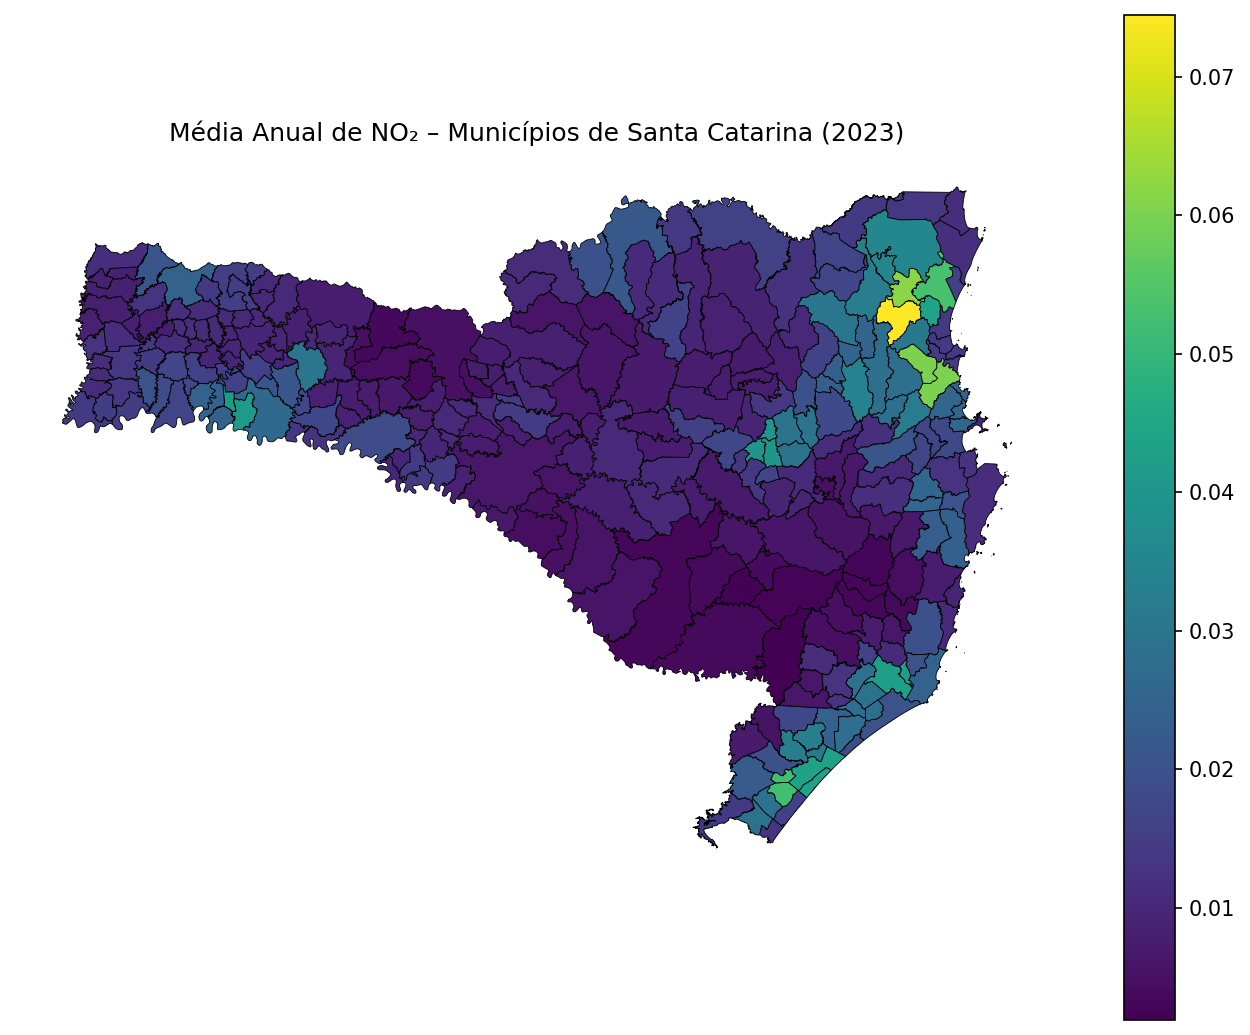

In [207]:
import geopandas as gpd
# NO2 está em (TSTEP, LAY, ROW, COL) -> pega só a camada 0
no2 = raster["NO2"].isel(LAY=0)
no2_mean_time = no2.mean(dim="TSTEP")

# TRANSFORMAR RASTER EM PONTOS (lon, lat, NO2)
lat = raster["LAT"].values 
lon = raster["LON"].values  
vals = no2_mean_time.values 

lat_flat = lat.ravel()
lon_flat = lon.ravel()
vals_flat = vals.ravel()

points = gpd.GeoDataFrame({"NO2": vals_flat},geometry=gpd.points_from_xy(lon_flat, lat_flat),crs="EPSG:4326")
col_mun = "NM_MUN"

# CENTRÓIDE DE CADA MUNICÍPIO + JOIN COM PONTO MAIS PRÓXIMO
sc_cent = sc[[col_mun, "geometry"]].copy()
sc_cent["geometry"] = sc_cent.geometry.centroid  # 1 ponto por município

# para cada centróide, encontra o ponto de NO2 mais próximo    -  ponto que aprendi!!
joined = gpd.sjoin_nearest(sc_cent, points, how="left")

# agora cada município tem um valor de NO2 associado (coluna "NO2")
sc_no2 = sc.merge(joined[[col_mun, "NO2"]], on=col_mun, how="left")

plt.figure(figsize=(9, 7), dpi=150)
ax = plt.gca()
sc_no2.plot(column="NO2", cmap="viridis", linewidth=0.4, edgecolor="black", legend=True, ax=ax)
ax.set_axis_off()
plt.title("Média Anual de NO₂ – Municípios de Santa Catarina (2023)", fontsize=12)
plt.tight_layout()
plt.show()

In [223]:
# nome da coluna de município
col_mun = "NM_MUN"   # mude se o seu shapefile tiver outro nome

# ranking: ordena do mais poluído para o menos
ranking_sc = (
    sc_no2[[col_mun, "NO2"]]
    .dropna(subset=["NO2"])              # tira município sem valor
    .sort_values("NO2", ascending=False) # maior NO2 primeiro
)

# top 10 municípios mais poluídos
top10_sc = ranking_sc.head(10)

print("Top 10 municípios de SC com maior NO₂ médio anual (2023):\n")
print(top10_sc.to_string(index=False, formatters={"NO2": lambda x: f"{x:.4f} ppm"}))

Top 10 municípios de SC com maior NO₂ médio anual (2023):

                   NM_MUN        NO2
             Massaranduba 0.0744 ppm
               Guaramirim 0.0620 ppm
                   Ilhota 0.0601 ppm
                   Itajaí 0.0601 ppm
                 Araquari 0.0533 ppm
                  Sombrio 0.0525 ppm
                     Ermo 0.0525 ppm
     São João do Itaperiú 0.0441 ppm
                Araranguá 0.0438 ppm
Balneário Arroio do Silva 0.0438 ppm


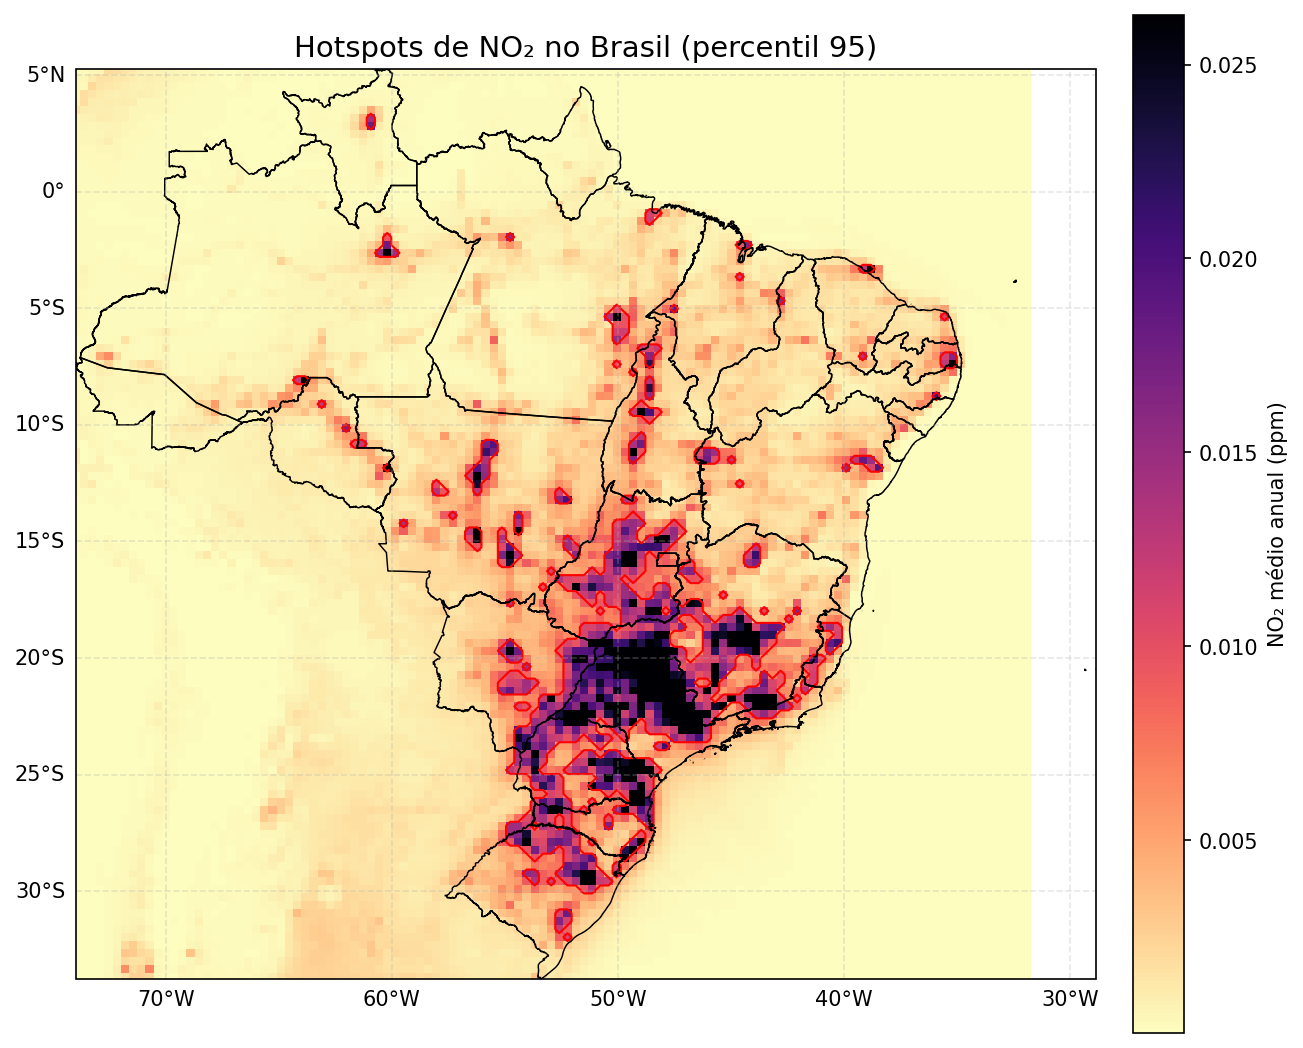

In [238]:
from scipy.ndimage import zoom

no2 = raster["NO2"].isel(LAY=0)             
no2_mean_time = no2.mean(dim="TSTEP")      

# suavizar
factor = 0.5  # pode aumentar para 6 ou diminuir para 2

no2_smooth = zoom(no2_mean_time.values, factor, order=1)  # bilinear

# criar lat/lon aproximados apenas para plot
lat = raster["LAT"].values[:,0]
lon = raster["LON"].values[0,:]

new_lat = np.linspace(lat.min(), lat.max(), no2_smooth.shape[0])
new_lon = np.linspace(lon.min(), lon.max(), no2_smooth.shape[1])

# Limites dos hotspots
threshold = np.nanpercentile(no2_smooth, 95)
hotspots = no2_smooth >= threshold

# shapefile BRASIL
br = gpd.read_file(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\Aula06\BR_UF")  
br = br.to_crs("EPSG:4326")

plt.figure(figsize=(9, 10), dpi=150)
ax = plt.axes(projection=ccrs.PlateCarree())

# fundo branco
ax.set_facecolor("white")
plt.gcf().set_facecolor("white")

# limitar o mapa à área do Brasil (usando o shapefile)
minx, miny, maxx, maxy = br.total_bounds
ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())


vmin = np.nanpercentile(no2_smooth, 5)
vmax = np.nanpercentile(no2_smooth, 99)

img = ax.pcolormesh(new_lon, new_lat, no2_smooth, cmap="magma_r", shading="auto", vmin=vmin, vmax=vmax)
ax.contour(new_lon, new_lat, hotspots, levels=[0.5], colors="red", linewidths=1.0)
br.boundary.plot(ax=ax, color="black", linewidth=0.7)

# grade de lat/lon discreta
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.3)
gl.top_labels = False
gl.right_labels = False


cbar = plt.colorbar(img, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label("NO₂ médio anual (ppm)")

plt.title("Hotspots de NO₂ no Brasil (percentil 95)", fontsize=14)
plt.tight_layout()
plt.show()